In [1]:
from splinecloud_scipy import load_spline, load_spline_surface, ParametricBivariateSpline
from time import time
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
%matplotlib widget

In [2]:
grid_size = 40

In [3]:
def surface_label(surf, axis):
    """Pull axis label from the surface if available, with log annotation."""
    label = getattr(surf, f'{axis}_label', None) or axis.upper()
    print
    log_flag = getattr(surf, f'log_{axis}', False)
    return f"{label} (log)" if log_flag else label

def log_formatter(x, pos):
    return f"$10^{{{int(x)}}}$"

# Test log Y surface

In [4]:
surf = load_spline_surface("srf_gKWPbS4au8jc")

x1_vals = np.linspace(1, 5, grid_size)
x2_vals = np.linspace(1, 3, grid_size)

x1_vals_ex = np.linspace(0.5, 5.5, grid_size)
x2_vals_ex = np.linspace(0.5, 3.5, grid_size)

print("log_x1:", surf.log_x1, "log_x2:", surf.log_x2, "log_y:", surf.log_y)

log_x1: False log_x2: False log_y: True


In [5]:
cols, data = surf.load_data()

In [6]:
U = np.linspace(0, 1, grid_size)
V = np.linspace(0, 1, grid_size)

## Evaluate surface for U-V grid

In [7]:
t0 = time()
X, Y, Z = surf(U, V)
t0 = time() - t0
t0

0.0007121562957763672

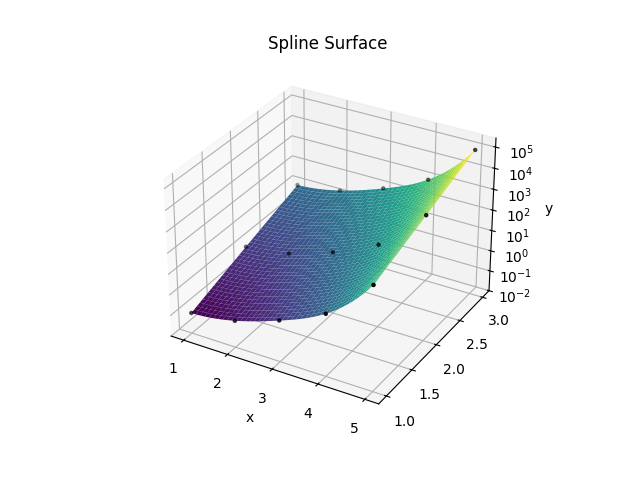

In [8]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

Z_log = np.log10(Z)
surfplot = ax.plot_surface(X, Y, Z_log, cmap='viridis', linewidth=0, antialiased=True)
ax.zaxis.set_major_formatter(FuncFormatter(log_formatter))
ax.scatter(data[:, 0],data[:, 1], np.log10(data[:, 2]), marker='.', color='black')

ax.set_xlabel(surf.x1_label)
ax.set_ylabel(surf.x2_label)
ax.set_zlabel(surf.y_label)
ax.set_zticks(np.arange(np.floor(Z_log.min()), np.ceil(Z_log.max()) + 1))
ax.set_title("Spline Surface")

plt.show()

## Evaluate surface for X1 and X2 values using 'eval_point'

### No extrapolation

In [9]:
X1_, X2_ = np.meshgrid(x1_vals, x2_vals)
Y_ = np.zeros_like(X1_)

t1 = time()
for i in range(X1_.shape[0]):
    for j in range(X2_.shape[0]):
        Y_[i, j] = surf.eval_point(X1_[i, j], X2_[i, j], extrapolate=False)

t1 = time() - t1
t1

0.35691285133361816

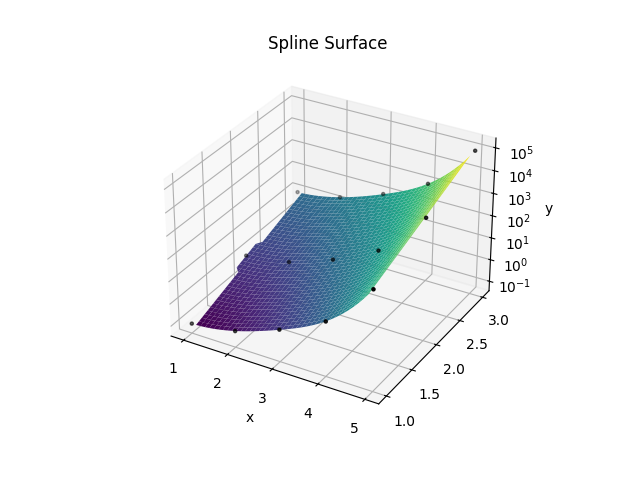

In [10]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

logY_ = np.log10(Y_)
surfplot = ax.plot_surface(X1_, X2_, logY_, cmap='viridis', linewidth=0, antialiased=True)
ax.zaxis.set_major_formatter(FuncFormatter(log_formatter))
ax.scatter(data[:, 0], data[:, 1], np.log10(data[:, 2]), marker='.', color='black')

ax.set_xlabel(surf.x1_label)
ax.set_ylabel(surf.x2_label)
ax.set_zlabel(surf.y_label)
ax.set_zticks(np.arange(np.floor(np.nanmin(logY_)), np.ceil(np.nanmax(logY_)) + 1))
ax.set_title("Spline Surface")
plt.show()

### Extrapolation

In [11]:
X1_, X2_ = np.meshgrid(x1_vals_ex, x2_vals_ex)
Y_ = np.zeros_like(X1_)

t1 = time()
for i in range(X1_.shape[0]):
    for j in range(X2_.shape[0]):
        Y_[i, j] = surf.eval_point(X1_[i, j], X2_[i, j], extrapolate=True)

t1 = time() - t1
t1

5.641839265823364

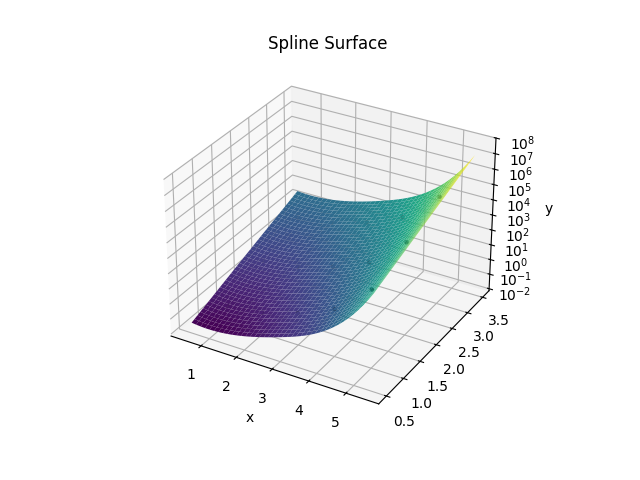

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

logY_ = np.log10(Y_)
surfplot = ax.plot_surface(X1_, X2_, logY_, cmap='viridis', linewidth=0, antialiased=True)
ax.zaxis.set_major_formatter(FuncFormatter(log_formatter))
ax.scatter(data[:, 0],data[:, 1], np.log10(data[:, 2]), marker='.', color='black')

ax.set_xlabel(surf.x1_label)
ax.set_ylabel(surf.x2_label)
ax.set_zlabel(surf.y_label)
ax.set_zticks(np.arange(np.floor(np.nanmin(logY_)), np.ceil(np.nanmax(logY_)) + 1))
ax.set_title("Spline Surface")
plt.show()

## Evaluate surface for X-Y values using 'eval_grid'

### No extrapolation

In [13]:
t2 = time()
X1_, X2_, Y_ = surf.eval_grid(x1_vals, x2_vals, extrapolate=False)
t2 = time() - t2
t2

0.4042997360229492

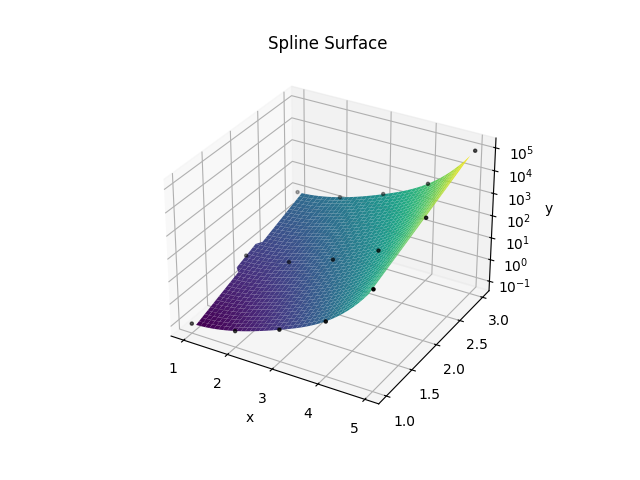

In [14]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

logY_ = np.log10(Y_)
surfplot = ax.plot_surface(X1_, X2_, logY_, cmap='viridis', linewidth=0, antialiased=True)
ax.zaxis.set_major_formatter(FuncFormatter(log_formatter))
ax.scatter(data[:, 0],data[:, 1], np.log10(data[:, 2]), marker='.', color='black')

ax.set_xlabel(surf.x1_label)
ax.set_ylabel(surf.x2_label)
ax.set_zlabel(surf.y_label)
ax.set_zticks(np.arange(np.floor(np.nanmin(logY_)), np.ceil(np.nanmax(logY_)) + 1))
ax.set_title("Spline Surface")
plt.show()

### Extrapolation

In [15]:
t2 = time()
X1_, X2_, Y_ = surf.eval_grid(x1_vals_ex, x2_vals_ex, extrapolate=True)
t2 = time() - t2
t2

5.507451295852661

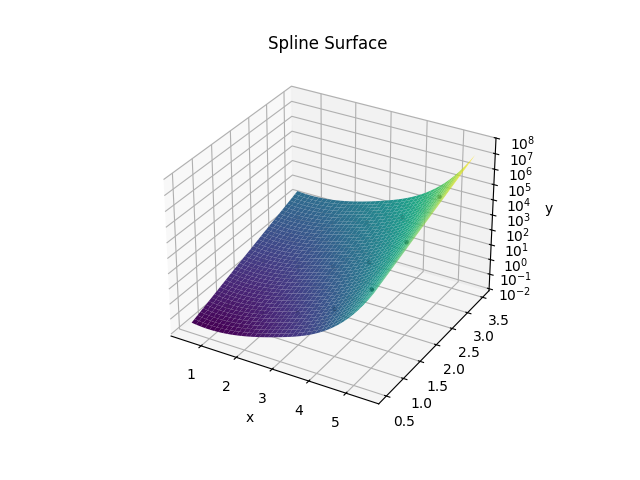

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

logY_ = np.log10(Y_)
surfplot = ax.plot_surface(X1_, X2_, logY_, cmap='viridis', linewidth=0, antialiased=True)
ax.zaxis.set_major_formatter(FuncFormatter(log_formatter))
ax.scatter(data[:, 0],data[:, 1], np.log10(data[:, 2]), marker='.', color='black')

ax.set_xlabel(surf.x1_label)
ax.set_ylabel(surf.x2_label)
ax.set_zlabel(surf.y_label)
ax.set_zticks(np.arange(np.floor(np.nanmin(logY_)), np.ceil(np.nanmax(logY_)) + 1))
ax.set_title("Spline Surface")
plt.show()

## Test gradient-based optimization

In [17]:
surf.eval(3.5, 2.5, compute_gradients=True, extrapolate=True)

(np.float64(83.4860542243975), (186.99090887635896, 192.36398174633774))

In [18]:
x1_avg = (x1_vals[0] + x1_vals[-1])/2
x2_avg = (x2_vals[0] + x2_vals[-1])/2
bounds = [[x1_vals[0], x1_vals[-1]], [x2_vals[0], x2_vals[-1]]]

In [19]:
def objective(x1x2):
    x1, x2 = x1x2
    y, grads = surf.eval(x1, x2, compute_gradients=True, extrapolate=True)
    return -y, np.array(grads)*(-1)

result = minimize(objective, x0=[x1_avg, x2_avg], bounds=bounds, jac=True, method='L-BFGS-B')
result

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -96717.31326644127
        x: [ 5.000e+00  3.000e+00]
      nit: 1
      jac: [-6.107e+05 -2.235e+05]
     nfev: 2
     njev: 2
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

## Test gradient-free optimization

In [20]:
def objective(x1x2):
    x1, x2 = x1x2
    y = surf.eval(x1, x2, compute_gradients=False, extrapolate=True)
    return -y

result = minimize(objective, x0=[x1_avg, x2_avg], bounds=bounds)
result

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -96717.31326644127
        x: [ 5.000e+00  3.000e+00]
      nit: 1
      jac: [-6.105e+05 -2.243e+05]
     nfev: 6
     njev: 2
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

# Test surface with log Y and X2 axes

In [21]:
surf = load_spline_surface("srf_MnRlGvcFYOpz") # surface with log x2 and log y

x1_vals = np.linspace(0, 5, grid_size)
x2_vals = np.power(10, np.linspace(0, 2, grid_size))

x1_vals_ex = np.linspace(-1, 6, grid_size)
x2_vals_ex = np.power(10, np.linspace(-1, 3, grid_size))

print("log_x1:", surf.log_x1, "log_x2:", surf.log_x2, "log_y:", surf.log_y)

log_x1: False log_x2: True log_y: True


In [22]:
cols, data = surf.load_data()

## Evaluate surface for U-V grid

In [23]:
t0 = time()
X1, X2, Y = surf(U, V)
t0 = time() - t0
t0

0.0009243488311767578

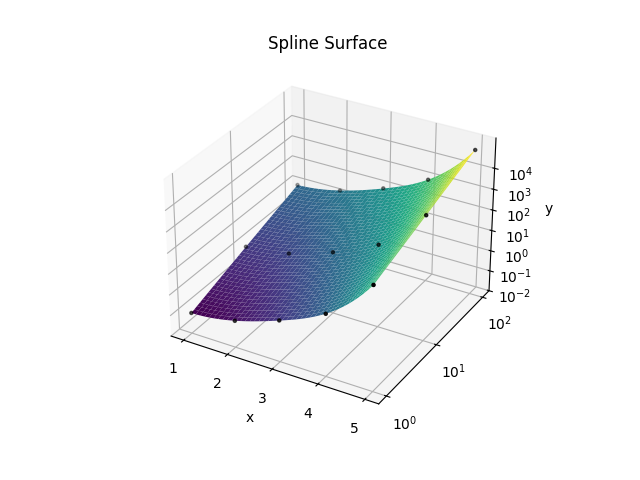

In [24]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

Y_log = np.log10(Y)
X2_log = np.log10(X2)

surfplot = ax.plot_surface(X1, X2_log, Y_log, cmap='viridis', linewidth=0, antialiased=True)
ax.zaxis.set_major_formatter(FuncFormatter(log_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(log_formatter))
ax.scatter(data[:, 0], np.log10(data[:, 1]), np.log10(data[:, 2]), marker='.', color='black')

ax.set_xlabel(surf.x1_label)
ax.set_ylabel(surf.x2_label)
ax.set_zlabel(surf.y_label)
ax.set_zticks(np.arange(np.floor(Y_log.min()), np.ceil(Y_log.max())))
ax.set_yticks(np.arange(np.floor(X2_log.min()), np.ceil(X2_log.max())))
ax.set_title("Spline Surface")

plt.show()

## Evaluate surface for X-Y values using 'eval_point'

### No extrapolation

In [25]:
X1_, X2_ = np.meshgrid(x1_vals, x2_vals)
Y_ = np.zeros_like(X1_)

t1 = time()
for i in range(X1_.shape[0]):
    for j in range(X2_.shape[0]):
        Y_[i, j] = surf.eval_point(X1_[i, j], X2_[i, j], extrapolate=False)

t1 = time() - t1
t1

1.178462028503418

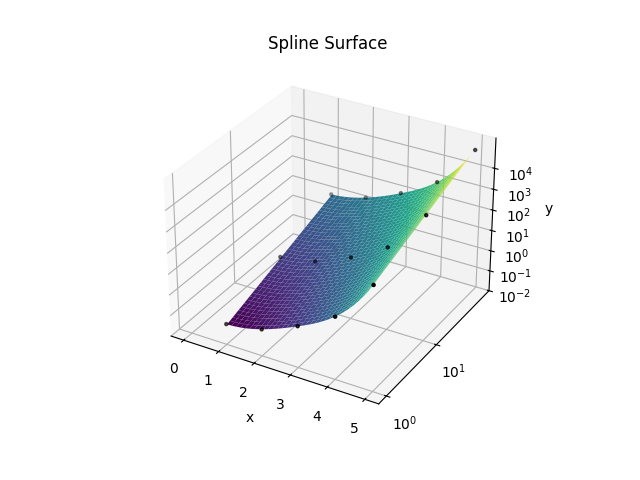

In [26]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

Y_log = np.log10(Y_)
X2_log = np.log10(X2_)

surfplot = ax.plot_surface(X1_, X2_log, Y_log, cmap='viridis', linewidth=0, antialiased=True)
ax.zaxis.set_major_formatter(FuncFormatter(log_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(log_formatter))
ax.scatter(data[:, 0], np.log10(data[:, 1]), np.log10(data[:, 2]), marker='.', color='black')

ax.set_xlabel(surf.x1_label)
ax.set_ylabel(surf.x2_label)
ax.set_zlabel(surf.y_label)
ax.set_zticks(np.arange(np.floor(np.nanmin(Y_log)), np.ceil(np.nanmax(Y_log))))
ax.set_yticks(np.arange(np.floor(np.nanmin(X2_log)), np.ceil(np.nanmax(X2_log))))
ax.set_title("Spline Surface")

plt.show()

### Extrapolation

In [27]:
X1_, X2_ = np.meshgrid(x1_vals_ex, x2_vals_ex)
Y_ = np.zeros_like(X1_)

t1 = time()
for i in range(X1_.shape[0]):
    for j in range(X2_.shape[0]):
        Y_[i, j] = surf.eval_point(X1_[i, j], X2_[i, j], extrapolate=True)

t1 = time() - t1
t1

8.98987865447998

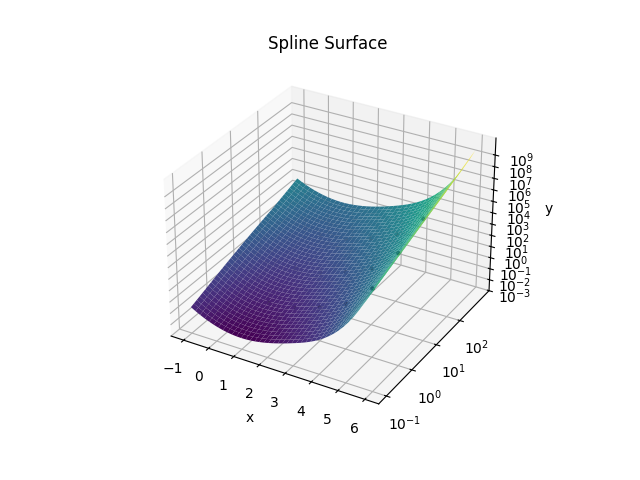

In [28]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

Y_log = np.log10(Y_)
X2_log = np.log10(X2_)

surfplot = ax.plot_surface(X1_, X2_log, Y_log, cmap='viridis', linewidth=0, antialiased=True)
ax.zaxis.set_major_formatter(FuncFormatter(log_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(log_formatter))
ax.scatter(data[:, 0], np.log10(data[:, 1]), np.log10(data[:, 2]), marker='.', color='black')

ax.set_xlabel(surf.x1_label)
ax.set_ylabel(surf.x2_label)
ax.set_zlabel(surf.y_label)
ax.set_zticks(np.arange(np.floor(np.nanmin(Y_log)), np.ceil(np.nanmax(Y_log))))
ax.set_yticks(np.arange(np.floor(np.nanmin(X2_log)), np.ceil(np.nanmax(X2_log))))
ax.set_title("Spline Surface")

plt.show()

## Evaluate surface for X-Y values using 'eval_grid'

### No extrapolation

In [29]:
t2 = time()
X1_, X2_, Y_ = surf.eval_grid(x1_vals, x2_vals, extrapolate=False)
t2 = time() - t2
t2

0.8868975639343262

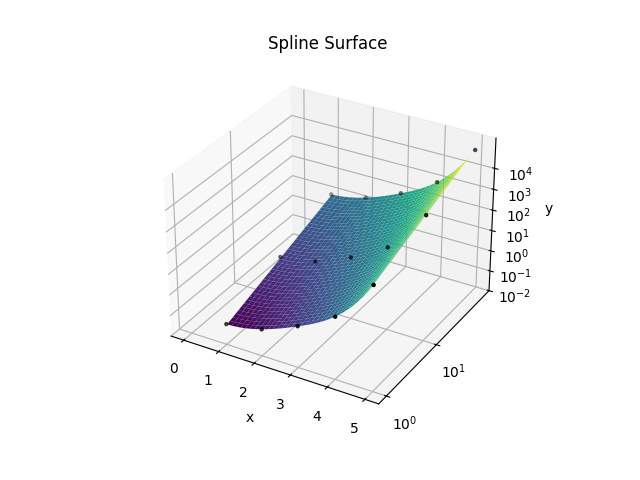

In [30]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

Y_log = np.log10(Y_)
X2_log = np.log10(X2_)

surfplot = ax.plot_surface(X1_, X2_log, Y_log, cmap='viridis', linewidth=0, antialiased=True)
ax.zaxis.set_major_formatter(FuncFormatter(log_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(log_formatter))
ax.scatter(data[:, 0], np.log10(data[:, 1]), np.log10(data[:, 2]), marker='.', color='black')

ax.set_xlabel(surf.x1_label)
ax.set_ylabel(surf.x2_label)
ax.set_zlabel(surf.y_label)
ax.set_zticks(np.arange(np.floor(np.nanmin(Y_log)), np.ceil(np.nanmax(Y_log))))
ax.set_yticks(np.arange(np.floor(np.nanmin(X2_log)), np.ceil(np.nanmax(X2_log))))
ax.set_title("Spline Surface")

plt.show()

### Extrapolation

In [31]:
t2 = time()
X1_, X2_, Y_ = surf.eval_grid(x1_vals_ex, x2_vals_ex, extrapolate=True)
t2 = time() - t2
t2

8.041428565979004

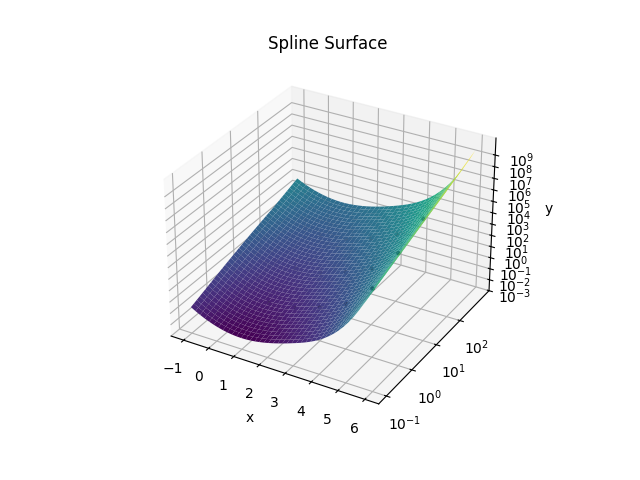

In [32]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

Y_log = np.log10(Y_)
X2_log = np.log10(X2_)

surfplot = ax.plot_surface(X1_, X2_log, Y_log, cmap='viridis', linewidth=0, antialiased=True)
ax.zaxis.set_major_formatter(FuncFormatter(log_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(log_formatter))
ax.scatter(data[:, 0], np.log10(data[:, 1]), np.log10(data[:, 2]), marker='.', color='black')

ax.set_xlabel(surf.x1_label)
ax.set_ylabel(surf.x2_label)
ax.set_zlabel(surf.y_label)
ax.set_zticks(np.arange(np.floor(np.nanmin(Y_log)), np.ceil(np.nanmax(Y_log))))
ax.set_yticks(np.arange(np.floor(np.nanmin(X2_log)), np.ceil(np.nanmax(X2_log))))
ax.set_title("Spline Surface")

plt.show()

## Test gradient-based optimization

In [33]:
x1_avg = (x1_vals[0] + x1_vals[-1])/2
x2_avg = (x2_vals[0] + x2_vals[-1])/2
bounds = [[x1_vals[0], x1_vals[-1]], [x2_vals[0], x2_vals[-1]]]

In [34]:
def objective(x1x2):
    x1, x2 = x1x2
    y, grads = surf.eval(x1, x2, compute_gradients=True, extrapolate=True)
    return -y, np.array(grads)*(-1)

result = minimize(objective, x0=[x1_avg, x2_avg], bounds=bounds, jac=True, method='L-BFGS-B')
result

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -96717.31326644127
        x: [ 5.000e+00  1.000e+02]
      nit: 2
      jac: [-6.107e+05 -9.707e+02]
     nfev: 3
     njev: 3
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

## Test gradient-free optimization

In [35]:
def objective(x1x2):
    x1, x2 = x1x2
    y = surf.eval(x1, x2, compute_gradients=False, extrapolate=True)
    return -y

result = minimize(objective, x0=[x1_avg, x2_avg], bounds=bounds)
result

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -96717.31326644127
        x: [ 5.000e+00  1.000e+02]
      nit: 2
      jac: [-6.105e+05 -9.740e+02]
     nfev: 9
     njev: 3
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>